# Datová analýza

Moje vybraná síť je síť odkazů komunit stránky [Reddit](https://www.reddit.com/). Tato stránka je složena z jednotlivých menších komunit, které se nazývají sub-reddity, které reprezentují uzly. Právě příspěvky v těchto menších sub-redditech se někdy odkazovali na jiné sub-reddity, což v naší sítí tvoří hrany mezi uzly. Síť je **orientovaná**, **s ohodnocením hran**, **časová** a **s atributy uzlů a hran**.

**Statistika sítě od autora datasetu:**

| Statistika                 | Hodnota                         |
|----------------------------|---------------------------------|
| Počet uzlů (subreddity)    | 55 863                          |
| Počet hran (hyperlinky)    | 858 490                         |
| Ohodnocení hran            | -1 nebo +1                      |
| Atributy hran              | Vektory textových vlastností    |
| Časové období              | leden 2014 – duben 2017         |


Vidíme, že ohodnocení hran může být buďto -1 nebo +1, což značí, zda se jedná o pozitivní nebo negativní odkaz mezi dvěma sub-reddity. Atributy hran jsou reprezentovány vektory textových vlastností, které obsahují informace o obsahu příspěvků, které vytvořily danou hyperlinku mezi dvěma sub-reddity. Tyto vektory mohou být využity pro analýzu témat, sentimentu nebo dalších charakteristik spojených s danými odkazy než o analýzu samotné struktury sítě.

Spíše vidíme, že se jedná síť převážně pro oblast analýzy sentimentu a vztahů mezi online komunitami spojené s hlubokým učením. My si pouze vezmeme jednotlivé hrany, uzly a časové období pro naši analýzu.

Odkaz na dataset nelznete [zde](https://snap.stanford.edu/data/soc-RedditHyperlinks.html).

## Načtení knihoven

In [1]:
import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from multiprocessing import Pool
from pathlib import Path

In [2]:
SAVE_PATH = Path("../results/project_analysis")
SAVE_PATH.mkdir(parents=True, exist_ok=True)

## Načtení datasetu

Dataset obsahuje dva soubory, jeden s odkazy z titulků příspěvků a druhý s odkazy z těla příspěvků. Jelikož v každém z těchto souborů jsou různé odkazy, sloučením dostaneme kompletní síť.

Součin počtu uzlů a průměrného stupně sítě je pseudo-metrika pro výběr datasetu, který musel být větší než **500 000**.

### Body

In [3]:
df_reddit_body = pd.read_csv('../data/soc-redditHyperlinks-body.tsv', sep='\t')

df_reddit_body = df_reddit_body[['SOURCE_SUBREDDIT', 'TARGET_SUBREDDIT', 'TIMESTAMP']]

G_body = nx.from_pandas_edgelist(df_reddit_body, source='SOURCE_SUBREDDIT', target='TARGET_SUBREDDIT')

num_nodes_body = G_body.number_of_nodes()
num_edges_body = G_body.number_of_edges()
avg_degree_body = (2 * num_edges_body) / num_nodes_body

print(f"Nodes: {num_nodes_body:,}")
print(f"Edges: {num_edges_body:,}")
print(f"Average Degree: {avg_degree_body:,.4f}")
print(f"Multiplication of Nodes and Average degree: {num_nodes_body * avg_degree_body:,}")

Nodes: 35,776
Edges: 124,330
Average Degree: 6.9505
Multiplication of Nodes and Average degree: 248,660.0


### Title

In [4]:
df_reddit_title = pd.read_csv('../data/soc-redditHyperlinks-title.tsv', sep='\t')

df_reddit_title = df_reddit_title[['SOURCE_SUBREDDIT', 'TARGET_SUBREDDIT', 'TIMESTAMP']]

G_title = nx.from_pandas_edgelist(df_reddit_title, source='SOURCE_SUBREDDIT', target='TARGET_SUBREDDIT')

num_nodes_title = G_title.number_of_nodes()
num_edges_title = G_title.number_of_edges()
avg_degree_title = (2 * num_edges_title) / num_nodes_title

print(f"Nodes: {num_nodes_title:,}")
print(f"Edges: {num_edges_title:,}")
print(f"Average Degree: {avg_degree_title:,.4f}")
print(f"Multiplication of Nodes and Average degree: {num_nodes_title * avg_degree_title:,}")

Nodes: 54,075
Edges: 220,151
Average Degree: 8.1424
Multiplication of Nodes and Average degree: 440,302.0


### Dohromady

In [5]:
df_reddit_merged = pd.concat([
    df_reddit_body[['SOURCE_SUBREDDIT', 'TARGET_SUBREDDIT', 'TIMESTAMP']],
    df_reddit_title[['SOURCE_SUBREDDIT', 'TARGET_SUBREDDIT', 'TIMESTAMP']]
], ignore_index=True)

df_reddit_merged = df_reddit_merged.drop_duplicates(subset=['SOURCE_SUBREDDIT', 'TARGET_SUBREDDIT', 'TIMESTAMP'])

G_merged = nx.from_pandas_edgelist(df_reddit_merged, source='SOURCE_SUBREDDIT', target='TARGET_SUBREDDIT')

num_nodes_merged = G_merged.number_of_nodes()
num_edges_merged = G_merged.number_of_edges()
avg_degree_merged = (2 * num_edges_merged) / num_nodes_merged

print(f"Nodes: {num_nodes_merged:,}")
print(f"Edges: {num_edges_merged:,}")
print(f"Average Degree: {avg_degree_merged:,.4f}")
print(f"Multiplication of Nodes and Average degree: {num_nodes_merged * avg_degree_merged:,}")

Nodes: 67,180
Edges: 309,667
Average Degree: 9.2190
Multiplication of Nodes and Average degree: 619,334.0


In [6]:
df_reddit_merged

,SOURCE_SUBREDDIT,TARGET_SUBREDDIT,TIMESTAMP
0,leagueoflegends,teamredditteams,2013-12-31 16:39:58
1,theredlion,soccer,2013-12-31 18:18:37
2,inlandempire,bikela,2014-01-01 14:54:35
3,nfl,cfb,2013-12-31 17:37:55
4,playmygame,gamedev,2014-01-01 02:51:13
...,...,...,...
858482,brasilonreddit,roadcam,2017-04-30 16:47:50
858484,peoplewhosayheck,spiderman,2017-04-30 16:36:07
858485,vzla,wtf,2017-04-30 15:50:07
858486,denverbroncos,nfl,2017-04-30 16:11:30


# Základní statistiky sítí

## Počet uzlů 

In [7]:
number_of_nodes = G_merged.number_of_nodes()
print(f"{number_of_nodes:,}".replace(",", " "))

67 180


## Počet hran

In [8]:
number_of_edges = G_merged.number_of_edges()
print(f"{number_of_edges:,}".replace(",", " "))

309 667


## Průměrný stupeň sítí

In [9]:
average_degree = (2 * number_of_edges) / number_of_nodes
average_degree

9.219023518904436

## Hustota sítě

In [10]:
density = nx.density(G_merged)
density

0.0001372307345882558

## Maximální stupeň sítí

In [11]:
max_degree = max(dict(G_merged.degree()).values())  # pyright: ignore[reportCallIssue]
print(f"{max_degree:,}".replace(",", " "))

5 547


## Počet komponent

In [12]:
num_components = nx.number_connected_components(G_merged)
num_components

712

### Frekvence komponent podle velikosti

In [13]:
components_dict = {i: c for i, c in enumerate(nx.connected_components(G_merged))}
component_sizes = {i: len(c) for i, c in components_dict.items()}

component_size_freq = Counter(component_sizes.values())
for size, freq in sorted(component_size_freq.items()):
    print(f"Size: {size:,} nodes - Frequency: {freq:,}".replace(",", " "))


Size: 2 nodes - Frequency: 646
Size: 3 nodes - Frequency: 42
Size: 4 nodes - Frequency: 14
Size: 5 nodes - Frequency: 3
Size: 6 nodes - Frequency: 2
Size: 7 nodes - Frequency: 2
Size: 8 nodes - Frequency: 1
Size: 9 nodes - Frequency: 1
Size: 65 648 nodes - Frequency: 1


### Velikost největší komponenty

In [14]:
biggest_cc = max(nx.connected_components(G_merged), key=len)
size_biggest_cc = len(biggest_cc)
print(f"{size_biggest_cc:,}".replace(",", " "))

65 648


## Cesty v sítí

In [15]:
if (SAVE_PATH / "reddit_network_analysis.csv").exists():
    print("File already exists, skipping SSSP computation.")
    df_sssp = pd.read_csv(SAVE_PATH / "reddit_network_analysis.csv")
else:
    print("Computing SSSP statistics...")
    largest_cc = max(nx.connected_components(G_merged), key=len) 
    G_largest_cc = G_merged.subgraph(largest_cc).copy()

    def sssp_stats(node):
        lengths = nx.single_source_shortest_path_length(G_largest_cc, node)
        dists = lengths.values()
        return sum(dists), max(dists)     # (sum_of_distances, eccentricity)

    nodes = list(G_largest_cc.nodes())
    N_biggest_component = len(nodes)

    with Pool() as p:
        results = p.map(sssp_stats, nodes)

File already exists, skipping SSSP computation.


### Průměrná délka cest v sítí

In [16]:
if (SAVE_PATH / "reddit_network_analysis.csv").exists():
    avg_shortest_path = df_sssp.loc[df_sssp['Metric'] == 'Average Shortest Path (Biggest Component)', 'Value'].iloc[0]
    print(f"Average Shortest Path (Biggest Component): {avg_shortest_path}")
else:
    sum_of_all_dists = sum(r[0] for r in results)

    avg_shortest_path = sum_of_all_dists / (N_biggest_component * (N_biggest_component - 1))
    print(f"Average Shortest Path (Biggest Component): {avg_shortest_path}")

Average Shortest Path (Biggest Component): 3.674454270945176


### Nejdelší cesta v sítí

In [17]:
if (SAVE_PATH / "reddit_network_analysis.csv").exists():
    diameter = df_sssp.loc[df_sssp['Metric'] == 'Diameter (Biggest Component)', 'Value'].iloc[0]
    print(f"Diameter (Biggest Component): {diameter}")
else:
    eccentricities  = [r[1] for r in results]

    diameter = max(eccentricities)
    print(f"Diameter (Biggest Component): {diameter}")

Diameter (Biggest Component): 14.0


## Shlukovací koeficient sítí

In [18]:
if (SAVE_PATH / "reddit_network_analysis.csv").exists():
    clustering_coefficient = df_sssp.loc[df_sssp['Metric'] == 'Clustering Coefficient', 'Value'].iloc[0]
    print(f"Clustering Coefficient: {clustering_coefficient}")
else:
    clustering_coefficient = nx.average_clustering(G_merged)
    print(f"Clustering Coefficient: {clustering_coefficient}")

Clustering Coefficient: 0.2169674012649235


## Centralita sítí

Největší centrality dle stupně pro jednotlivé uzly v síti.

In [19]:
top_n_centralities_count = 25

In [20]:
centrality = nx.degree_centrality(G_merged)

top_centrality = sorted(centrality.items(), key=lambda x: x[1], reverse=True)[:top_n_centralities_count]

for node, cent in top_centrality:
    print(f"{node}: {cent:.5f}")

askreddit: 0.08257
iama: 0.06849
subredditdrama: 0.05255
pics: 0.05063
bestof: 0.05045
funny: 0.04835
todayilearned: 0.04126
videos: 0.04082
titlegore: 0.03696
gaming: 0.03247
worldnews: 0.02711
news: 0.02571
writingprompts: 0.02420
gifs: 0.02386
wtf: 0.02356
drama: 0.02330
the_donald: 0.02297
conspiracy: 0.02169
science: 0.02136
movies: 0.01999
explainlikeimfive: 0.01965
politics: 0.01965
bitcoin: 0.01934
adviceanimals: 0.01922
showerthoughts: 0.01914


## Uložení výsledků analýzy

In [21]:
df_analysis = pd.DataFrame({
    'Metric': [
        'Number of Nodes',
        'Number of Edges',
        'Average Degree',
        'Density',
        'Max Degree',
        'Number of Components',
        'Size of Biggest Component',
        'Average Shortest Path (Biggest Component)',
        'Diameter (Biggest Component)',
        'Clustering Coefficient'
    ],
    'Value': [
        number_of_nodes,
        number_of_edges,
        average_degree,
        density,
        max_degree,
        num_components,
        size_biggest_cc,
        avg_shortest_path,
        diameter,
        clustering_coefficient
    ]
})
df_analysis.to_csv(SAVE_PATH / 'reddit_network_analysis.csv', index=False)

In [22]:
with open(SAVE_PATH / 'top_25_centralities.txt', 'w') as f:
    for node, cent in top_centrality:
        f.write(f"{node}: {cent:.5f}\n")

# Vizualizace statistik sítí

## Distribuce stupňů uzlů

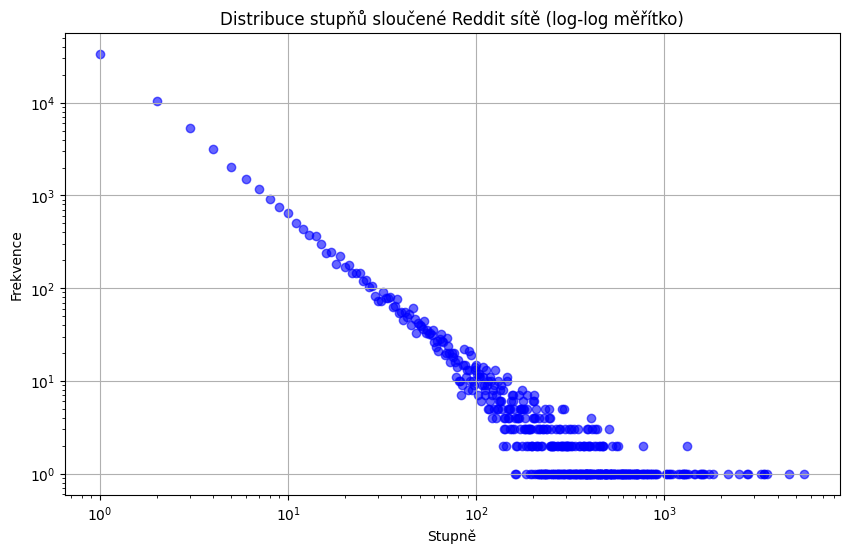

In [23]:
degrees = [degree for _, degree in G_merged.degree()] # pyright: ignore[reportCallIssue]
 
degree_counts = Counter(degrees)
deg, freq = zip(*sorted(degree_counts.items()))

plt.figure(figsize=(10, 6))
plt.scatter(deg, freq, alpha=0.6, color='blue')
plt.title(label='Distribuce stupňů sloučené Reddit sítě (log-log měřítko)')
plt.xlabel('Stupně')
plt.ylabel('Frekvence')
plt.yscale('log')
plt.xscale('log')
plt.grid(True)
plt.savefig(SAVE_PATH / 'reddit_degree_distribution.png', dpi=300)
plt.show()

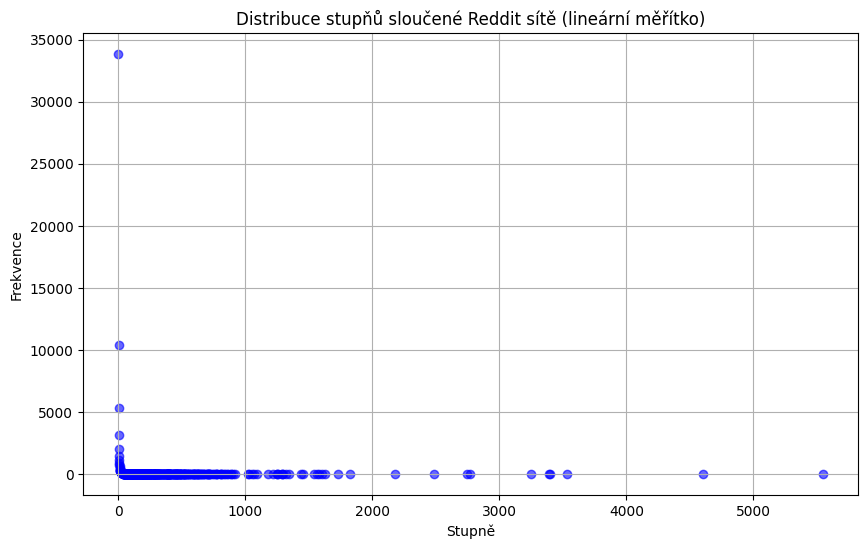

In [24]:
plt.figure(figsize=(10, 6))
plt.scatter(deg, freq, alpha=0.6, color='blue')
plt.title('Distribuce stupňů sloučené Reddit sítě (lineární měřítko)')
plt.xlabel('Stupně')
plt.ylabel('Frekvence')
plt.yscale('linear')
plt.xscale('linear')
plt.grid(True)
plt.savefig(SAVE_PATH / 'reddit_degree_distribution_linear.png', dpi=300)
plt.show()

## Velikosti komponent

In [25]:
component_size_counts = Counter(len(c) for c in nx.connected_components(G_merged)) 
component_sizes, component_freqs = zip(*sorted(component_size_counts.items()))

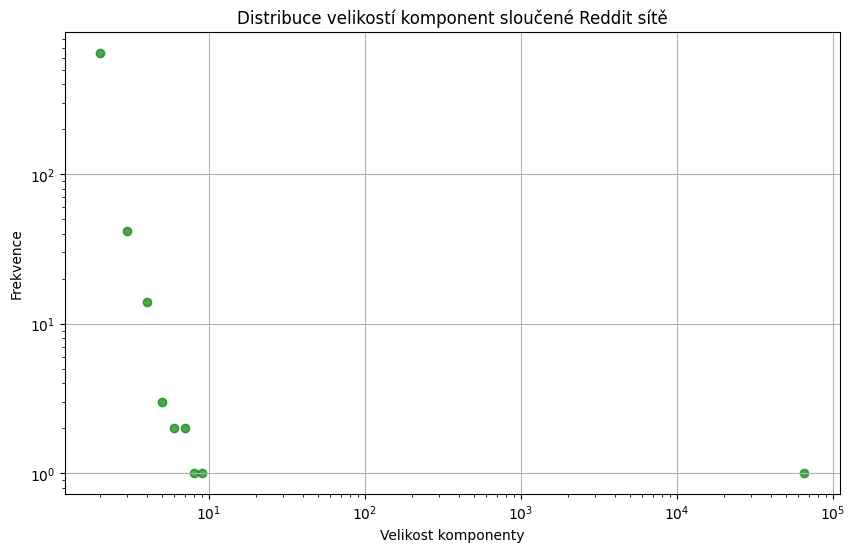

In [26]:
plt.figure(figsize=(10, 6))
plt.scatter(component_sizes, component_freqs, alpha=0.7, color='green')
plt.title('Distribuce velikostí komponent sloučené Reddit sítě')
plt.xlabel('Velikost komponenty')
plt.ylabel('Frekvence')
plt.yscale('log')
plt.xscale('log')
plt.grid(True)
plt.savefig(SAVE_PATH / 'reddit_component_size_distribution.png', dpi=300)
plt.show()

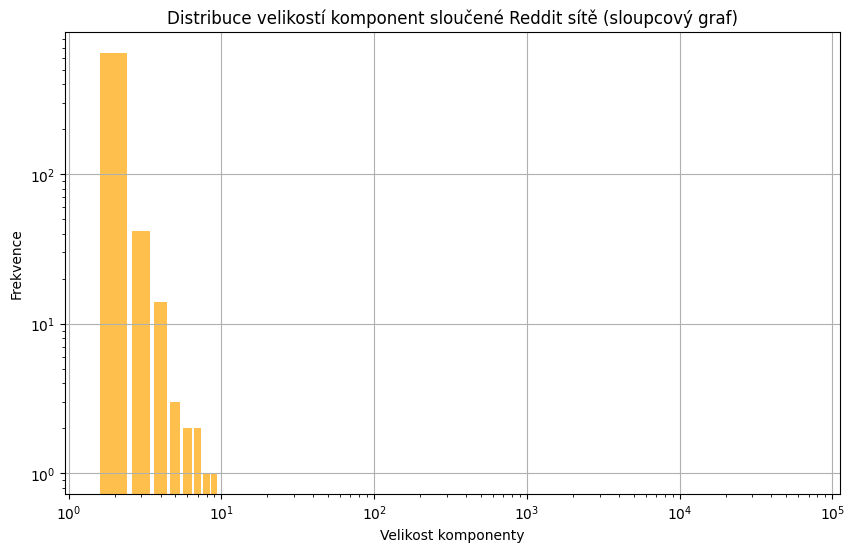

In [27]:
plt.figure(figsize=(10, 6))
plt.bar(component_sizes, component_freqs, color='orange', alpha=0.7)
plt.title('Distribuce velikostí komponent sloučené Reddit sítě (sloupcový graf)')
plt.xlabel('Velikost komponenty')
plt.ylabel('Frekvence')
plt.yscale('log')
plt.xscale('log')
plt.grid(True)
plt.savefig(SAVE_PATH / 'reddit_component_size_distribution_bar.png', dpi=300)
plt.show()

# Timestamp analýza

In [28]:
min_timestamp = df_reddit_merged['TIMESTAMP'].min()
max_timestamp = df_reddit_merged['TIMESTAMP'].max()

print(f"Min timestamp: {min_timestamp}")
print(f"Max timestamp: {max_timestamp}")

Min timestamp: 2013-12-31 16:20:20
Max timestamp: 2017-04-30 16:58:21


## Rozdíl mezi minimálním a maximálním timestampem

In [29]:
min_timestamp = pd.to_datetime(min_timestamp)
max_timestamp = pd.to_datetime(max_timestamp)
time_diff = max_timestamp - min_timestamp
time_diff_months = time_diff.days / 30.44  # average days in a month

print(f"Time difference: {time_diff}")
print(f"Time difference in months: {time_diff_months:,.2f}")

Time difference: 1216 days 00:38:01
Time difference in months: 39.95


Analýza časových razítek ukazuje, že data pokrývají období od 31. prosince 2013 do 30. dubna 2017. To znamená, že síť odkazů mezi subreddity byla sledována téměř 3,5 roku. Díky tomu lze zkoumat vývoj a změny v propojení komunit na Redditu v průběhu času, například vznik nových subredditu, změny v aktivitě nebo sezónní trendy.

## Rozdělení si dat na časové úseky



In [30]:
# TODO: rozhodnout o intervalech pro analýzu časové složky
# ! TODO
# ? TODO
# * TODO
# TODO: 

"""
4 intervaly (čtvrtiny)
5 intervalů (každý cca 8 měsíců)
6 intervalů (každý cca 6-7 měsíců)
8 intervalů (každý cca 5 měsíců)
"""

'\n4 intervaly (čtvrtiny)\n5 intervalů (každý cca 8 měsíců)\n6 intervalů (každý cca 6-7 měsíců)\n8 intervalů (každý cca 5 měsíců)\n'

## Základní statistiky sítí

## 